## 0. 라이브러리 및 전역 설정
필요한 패키지 설치 및 분석에 사용할 라이브러리를 한 번에 불러옵니다. 폰트 설정 포함.

In [1]:
# 패키지 설치
!pip install -q scikit-learn seaborn matplotlib xgboost scipy geopandas koreanize-matplotlib

# 기본
import pandas as pd
import numpy as np
import re
import ast

# 시각화
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import koreanize_matplotlib

# sklearn
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, classification_report, confusion_matrix
)

# 기타
import geopandas as gpd
from scipy.ndimage import gaussian_filter1d

# ── 전역 시각화 설정 ──
plt.style.use('ggplot')
matplotlib.rcParams['axes.unicode_minus'] = False



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. 데이터 로드
전처리 완료된 최종 데이터를 불러옵니다.

In [2]:
df = pd.read_csv("final_airbnb_without_Shinjuku.csv")
print(df.shape)
df.head()


(12222, 36)


,id,name,listing_url,price,room_type,property_type,accommodates,bedrooms,beds,bathrooms_text,...,host_identity_verified,calculated_host_listings_count,availability_365,instant_bookable,dist_to_station,stations_within_500m,dist_to_Tokyo,dist_to_Shibuya,land_price,dist_to_land
0,197677,Oshiage Holiday Apartment,https://www.airbnb.com/rooms/197677,"$12,600.00",Entire home/apt,Entire rental unit,2,1.0,2.0,1 bath,...,t,1,183,f,680.592170,0.0,8263.854679,16020.647615,565000,362.520859
1,1016831,5 mins Shibuya Cat modern sunny Shimokita,https://www.airbnb.com/rooms/1016831,"$24,143.00",Private room,Private room in home,2,1.0,4.0,1 shared bath,...,t,1,80,f,401.085320,1.0,11041.134716,3329.576245,996000,296.612219
2,1196177,Homestay at Host's House - Senju-Ohashi Station,https://www.airbnb.com/rooms/1196177,"$8,795.00",Private room,Private room in home,3,1.0,8.0,1.5 baths,...,t,1,253,f,234.042950,1.0,9260.577789,15877.776416,860000,309.270900
3,1268465,No share Private APT 8 min from Ebisu station,https://www.airbnb.com/rooms/1268465,"$11,699.00",Private room,Private room in rental unit,2,0.0,1.0,Private half-bath,...,t,1,21,t,980.558026,0.0,8514.985876,2820.236212,1470000,194.130389
4,1298200,"2 Bed Room + 2 Toilets, drop off luggage from 9am",https://www.airbnb.com/rooms/1298200,"$18,575.00",Entire home/apt,Entire home,3,2.0,4.0,2 baths,...,t,6,129,f,462.263242,1.0,12446.337616,20097.190843,780000,485.053012


## 2. 전처리
- t/f 이진화 · price 숫자화 · IQR 이상치 제거 · log 변환
- 퍼센트 변수 숫자화 · 욕실 파싱 · 편의시설 이진변수 · 거리 km 변환 · 공시지가 로그 변환


In [3]:
# ── [1] 이진 변수 변환 (t/f → 1/0) ──
binary_cols = ['host_is_superhost', 'host_identity_verified', 'instant_bookable']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'t': 1, 'f': 0, True: 1, False: 0})

# ── [2] 가격 정리 → IQR 이상치 제거 → 로그 변환 ──
df['price'] = (
    df['price'].astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)
lower = df['price'].quantile(0.01)
upper = df['price'].quantile(0.99)
df = df[(df['price'] >= lower) & (df['price'] <= upper)].copy()
df['log_price'] = np.log1p(df['price'])
print('이상치 제거 후:', df.shape)
print(df[['price', 'log_price']].describe().round(2))

# ── [3] 퍼센트 변수 숫자화 ──
for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in df.columns:
        df[col] = (
            df[col].astype(str)
            .str.replace('%', '', regex=False)
            .replace('nan', np.nan)
            .astype(float)
        )

# ── [4] 욕실 수 파싱 ──
def extract_bathrooms(text):
    text = str(text).lower()
    if 'half-bath' in text or 'half bath' in text:
        return 0.5
    m = re.search(r'(\d+\.?\d*)', text)
    return float(m.group(1)) if m else np.nan

df['bathrooms'] = df['bathrooms_text'].apply(extract_bathrooms)

# ── [5] 편의시설 이진변수 생성 ──
def has_amenity(x, keyword):
    try:
        items = ast.literal_eval(x)
        return int(keyword.lower() in ' '.join(items).lower())
    except:
        return 0

# 모델용 has_* 변수
important_amenities = {
    'has_wifi': 'Wifi', 'has_air_conditioning': 'Air conditioning',
    'has_kitchen': 'Kitchen', 'has_washer': 'Washer',
    'has_tv': 'TV', 'has_elevator': 'Elevator', 'has_self_checkin': 'Self check-in'
}
for new_col, keyword in important_amenities.items():
    df[new_col] = df['amenities'].apply(lambda x: has_amenity(x, keyword))

# 분석용 추가 편의시설 변수 (가격 기여도 계산에 사용)
extra_amenities = {
    'TV': 'TV', 'Iron': 'Iron',
    'Dedicated workspace': 'Dedicated workspace', 'Bidet': 'Bidet'
}
for label, keyword in extra_amenities.items():
    df[label] = df['amenities'].apply(lambda x: has_amenity(x, keyword))

# ── [6] 거리 km 변환 + 공시지가 로그 변환 ──
for col in ['dist_to_station', 'dist_to_Tokyo', 'dist_to_Shibuya', 'dist_to_land']:
    if col in df.columns:
        df[col + '_km'] = df[col] / 1000

df['log_land_price'] = np.log1p(df['land_price'])
print('전처리 완료.')


이상치 제거 후: (11977, 37)
          price  log_price
count  11977.00   11977.00
mean   15341.39       9.54
std     7248.64       0.43
min     4972.00       8.51
25%    10269.00       9.24
50%    13521.00       9.51
75%    18286.00       9.81
max    50715.00      10.83
전처리 완료.


## [부록] 신주쿠 포함 vs 제외 비교 — 제외 근거 분석

=== 신주쿠 vs 기타 지역 가격 비교 ===
신주쿠  중앙값: nan엔  /  건수: 0건  (0.0%)
기타    중앙값: 13,521엔  /  건수: 11,977건
가격 차이: +nan엔

전체 데이터: 11,977건 → 신주쿠 제외 후: 11,977건


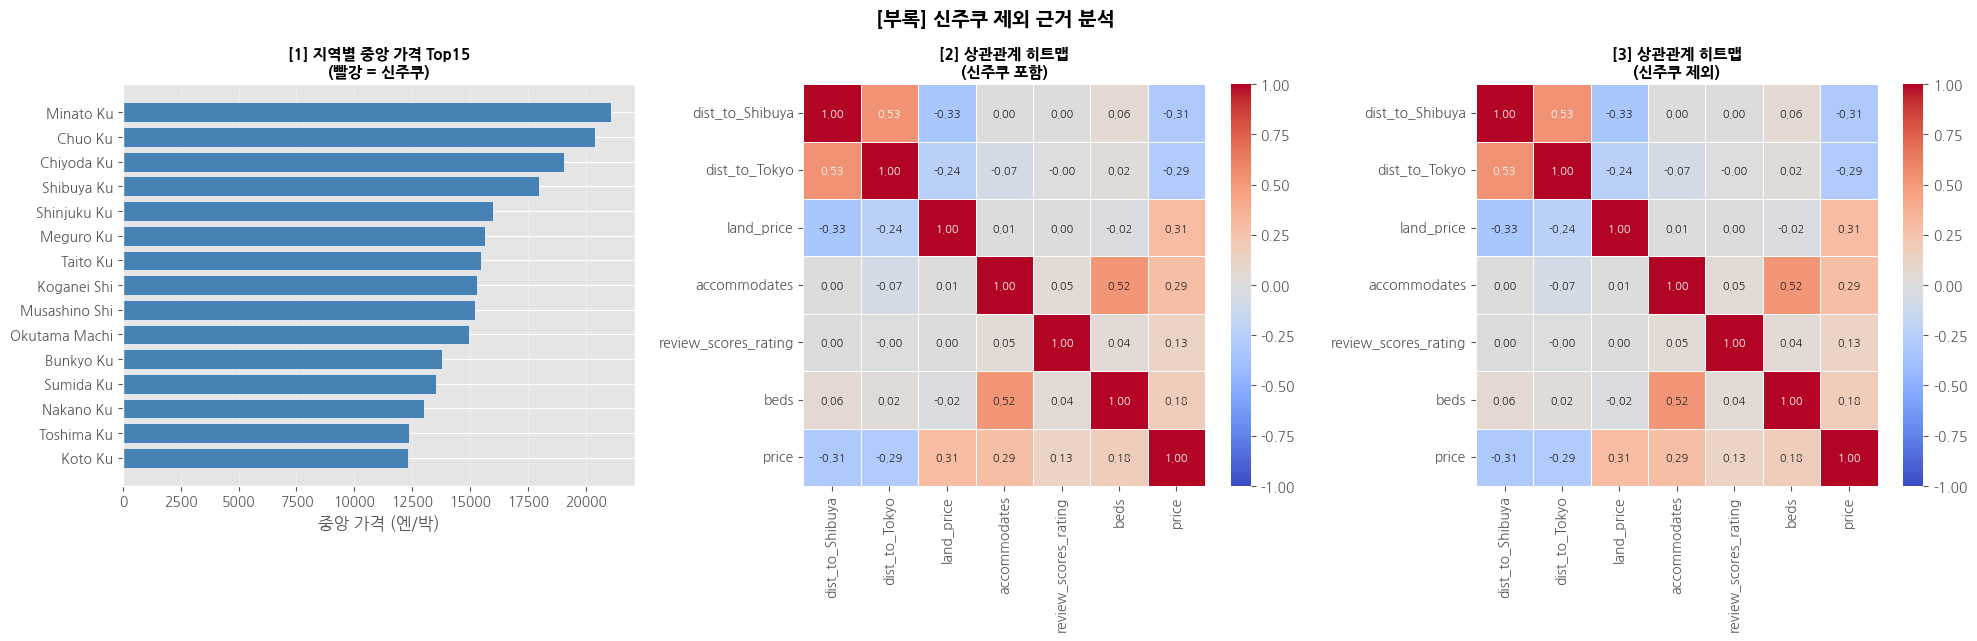

In [4]:
# ============================================================
# [부록] 신주쿠 포함 vs 제외 비교 — 제외 근거 분석
# ============================================================

df_with    = pd.read_csv("final_airbnb.csv")
df_without = pd.read_csv("final_airbnb_without_Shinjuku.csv")

# 가격 정리 (두 데이터 동일하게 전처리)
def clean_price(df):
    df = df.copy()
    df['price'] = (
        df['price'].astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
    )
    lower = df['price'].quantile(0.01)
    upper = df['price'].quantile(0.99)
    return df[(df['price'] >= lower) & (df['price'] <= upper)].copy()

df_with    = clean_price(df_with)
df_without = clean_price(df_without)

shinjuku = df_with[df_with['neighbourhood_cleansed'] == 'Shinjuku']['price']
others   = df_with[df_with['neighbourhood_cleansed'] != 'Shinjuku']['price']

# ── 수치 요약 ──
print('=== 신주쿠 vs 기타 지역 가격 비교 ===')
print(f'신주쿠  중앙값: {shinjuku.median():,.0f}엔  /  건수: {len(shinjuku):,}건  ({len(shinjuku)/len(df_with)*100:.1f}%)')
print(f'기타    중앙값: {others.median():,.0f}엔  /  건수: {len(others):,}건')
print(f'가격 차이: {shinjuku.median() - others.median():+,.0f}엔')
print(f'\n전체 데이터: {len(df_with):,}건 → 신주쿠 제외 후: {len(df_without):,}건')

# ── 시각화 ──
heatmap_cols = ['dist_to_Shibuya', 'dist_to_Tokyo', 'land_price',
                'accommodates', 'review_scores_rating', 'beds', 'price']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('[부록] 신주쿠 제외 근거 분석', fontsize=14, fontweight='bold')

# [1] 지역별 중앙 가격 Top15 (신주쿠 강조)
ax1 = axes[0]
neigh_price = (df_with.groupby('neighbourhood_cleansed')['price']
               .median().sort_values(ascending=False).head(15))
colors = ['#e74c3c' if n == 'Shinjuku' else 'steelblue' for n in neigh_price.index]
ax1.barh(neigh_price.index[::-1], neigh_price.values[::-1], color=colors[::-1], edgecolor='white')
ax1.set_title('[1] 지역별 중앙 가격 Top15\n(빨강 = 신주쿠)', fontsize=11, fontweight='bold')
ax1.set_xlabel('중앙 가격 (엔/박)')
ax1.grid(axis='x', alpha=0.3)

# [2] 상관관계 히트맵 — 신주쿠 포함
ax2 = axes[1]
cols_w = [c for c in heatmap_cols if c in df_with.columns]
sns.heatmap(df_with[cols_w].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, square=True,
            ax=ax2, annot_kws={'size': 8})
ax2.set_title('[2] 상관관계 히트맵\n(신주쿠 포함)', fontsize=11, fontweight='bold')

# [3] 상관관계 히트맵 — 신주쿠 제외
ax3 = axes[2]
cols_wo = [c for c in heatmap_cols if c in df_without.columns]
sns.heatmap(df_without[cols_wo].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, square=True,
            ax=ax3, annot_kws={'size': 8})
ax3.set_title('[3] 상관관계 히트맵\n(신주쿠 제외)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('appendix_01_shinjuku_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 변수 정의 및 모델 학습
변수군 정의 → X/y 분리 → 전처리 파이프라인 → train/test split → 3개 모델 학습

In [5]:
# ── [1] 변수군 정의 ──
location_features = [
    'neighbourhood_cleansed', 'dist_to_station_km', 'stations_within_500m',
    'dist_to_Tokyo_km', 'dist_to_Shibuya_km', 'log_land_price', 'dist_to_land_km'
]
internal_features = [
    'room_type', 'property_type', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'has_wifi', 'has_air_conditioning', 'has_kitchen', 'has_washer',
    'has_tv', 'has_elevator', 'has_self_checkin'
]
review_features = [
    'review_scores_rating', 'review_scores_value', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_accuracy', 'number_of_reviews'
]
host_features = [
    'host_is_superhost', 'host_response_rate', 'host_acceptance_rate',
    'host_identity_verified', 'calculated_host_listings_count'
]
booking_features = ['minimum_nights', 'availability_365', 'instant_bookable']

feature_cols = [c for c in
    location_features + internal_features + review_features + host_features + booking_features
    if c in df.columns]
print('사용 변수 수:', len(feature_cols))

# ── [2] X/y 분리 ──
X = df[feature_cols].copy()
y = df['log_price'].copy()

numeric_features     = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# ── [3] 전처리 파이프라인 ──
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# ── [4] Train/Test Split ──
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, '/ Test:', X_test.shape)

# ── [5] 3개 모델 학습 ──
model_defs = {
    'Ridge':            Ridge(alpha=1.0),
    'RandomForest':     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, random_state=42)
}
pipelines = {}
for name, model in model_defs.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(f'{name} 학습 완료')


사용 변수 수: 36
Train: (9581, 36) / Test: (2396, 36)
Ridge 학습 완료
RandomForest 학습 완료
GradientBoosting 학습 완료


## 4. 모델 평가
성능 비교 → Best Model 선정 → 5-Fold 교차검증 → 실제 vs 예측 시각화

           Model     R²  RMSE (log)  MAE (log)  MAE (¥)
    RandomForest 0.6972      0.2349     0.1665   2609.0
GradientBoosting 0.6106      0.2664     0.2022   3151.0
           Ridge 0.5084      0.2993     0.2324   3645.0

[선택 모델]: RandomForest

=== 5-Fold 교차검증 ===
Ridge               : R² 0.474 (±0.008)
RandomForest        : R² 0.677 (±0.005)
GradientBoosting    : R² 0.597 (±0.014)


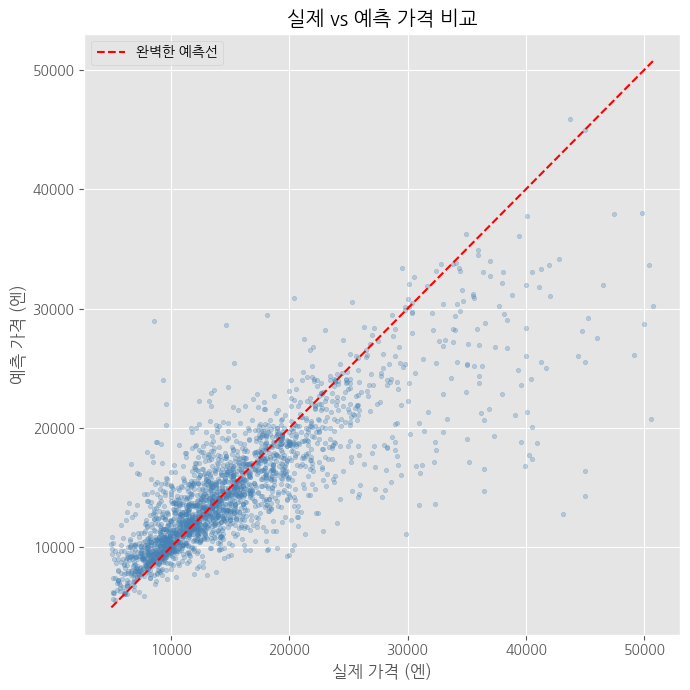

In [6]:
# ── [1] 성능 비교 ──
results = []
for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    results.append({
        'Model':      name,
        'R²':         round(r2_score(y_test, y_pred), 4),
        'RMSE (log)': round(mean_squared_error(y_test, y_pred) ** 0.5, 4),
        'MAE (log)':  round(mean_absolute_error(y_test, y_pred), 4),
        'MAE (¥)':    round(mean_absolute_error(np.expm1(y_test), np.expm1(y_pred)), 0)
    })
results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print(results_df.to_string(index=False))

# ── [2] Best Model 선정 ──
best_model_name = results_df.iloc[0]['Model']
best_pipe = pipelines[best_model_name]
print(f'\n[선택 모델]: {best_model_name}')

ohe_cols = (
    best_pipe.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_features).tolist()
)
all_feature_names = numeric_features + ohe_cols

# ── [3] 5-Fold 교차검증 ──
print('\n=== 5-Fold 교차검증 ===')
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')
    print(f'{name:20s}: R² {scores.mean():.3f} (±{scores.std():.3f})')

# ── [4] 실제 vs 예측 산점도 ──
y_actual   = np.expm1(y_test)
y_pred_plot = np.expm1(best_pipe.predict(X_test))

plt.figure(figsize=(7, 7))
plt.scatter(y_actual, y_pred_plot, alpha=0.3, s=10, color='steelblue')
plt.plot([y_actual.min(), y_actual.max()],
         [y_actual.min(), y_actual.max()], 'r--', linewidth=1.5, label='완벽한 예측선')
plt.xlabel('실제 가격 (엔)')
plt.ylabel('예측 가격 (엔)')
plt.title('실제 vs 예측 가격 비교')
plt.legend()
plt.tight_layout()
plt.savefig('result_actual_vs_pred.png', dpi=150)
plt.show()


## 5. 가격 영향 변수 분석
Feature Importance Top 20 · 변수군별 중요도 · 상관관계 바 · 히트맵 · 슈퍼호스트 효과

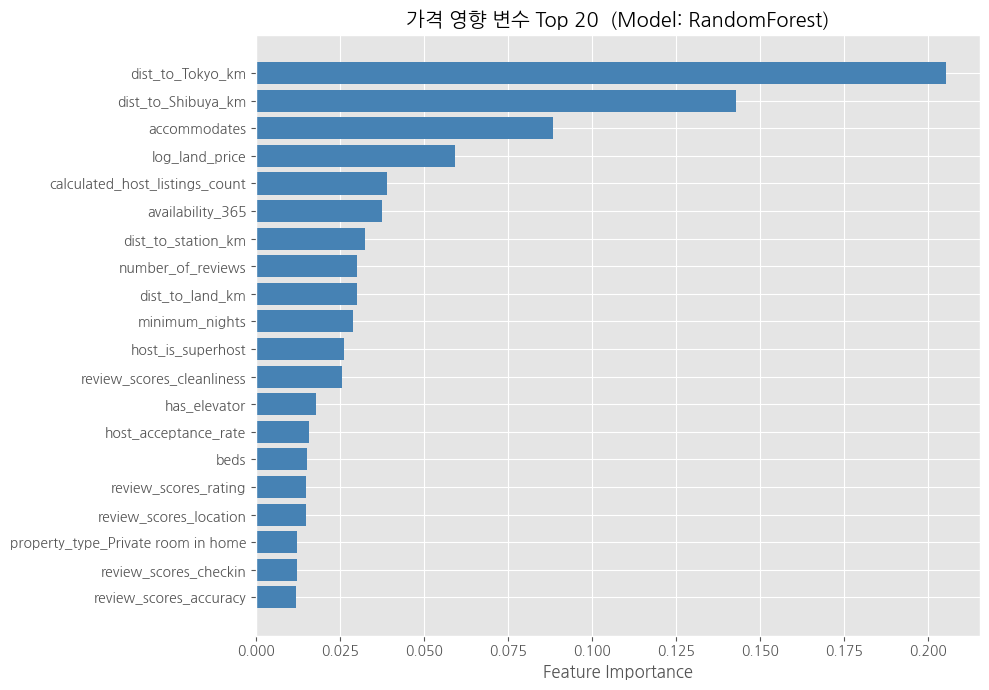

                           feature  importance
                  dist_to_Tokyo_km    0.205145
                dist_to_Shibuya_km    0.142889
                      accommodates    0.088395
                    log_land_price    0.059159
    calculated_host_listings_count    0.039055
                  availability_365    0.037572
                dist_to_station_km    0.032426
                 number_of_reviews    0.030074
                   dist_to_land_km    0.029864
                    minimum_nights    0.028924
                 host_is_superhost    0.025987
         review_scores_cleanliness    0.025658
                      has_elevator    0.017834
              host_acceptance_rate    0.015576
                              beds    0.014978
              review_scores_rating    0.014882
            review_scores_location    0.014815
property_type_Private room in home    0.012273
             review_scores_checkin    0.012001
            review_scores_accuracy    0.011918


In [28]:
# ── Feature Importance Top 20 ──
importances = best_pipe.named_steps['model'].feature_importances_
fi_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})\
          .sort_values('importance', ascending=False).reset_index(drop=True)

top20 = fi_df.head(20)
plt.figure(figsize=(10, 7))
plt.barh(top20['feature'][::-1], top20['importance'][::-1], color='steelblue')
plt.xlabel('Feature Importance')
plt.title(f'가격 영향 변수 Top 20  (Model: {best_model_name})')
plt.tight_layout()
plt.savefig('result_01_feature_importance.png', dpi=150)
plt.show()
print(fi_df.head(20).to_string(index=False))



--- 변수군별 중요도 ---
        group  importance  비율(%)
     Location      0.4963   49.6
Internal Spec      0.2105   21.0
       Review      0.1308   13.1
         Host      0.0925    9.2
      Booking      0.0699    7.0


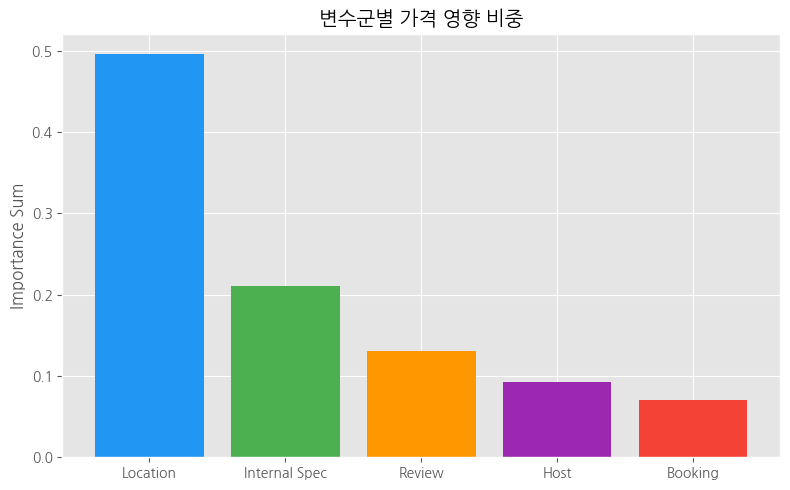

In [8]:
# ── 변수군별 중요도 ──
def group_importance(fi_df, feature_list, label):
    mask = fi_df['feature'].apply(
        lambda x: any(x == f or x.startswith(f + '_') for f in feature_list))
    return {'group': label, 'importance': round(fi_df.loc[mask, 'importance'].sum(), 4)}

group_df = pd.DataFrame([
    group_importance(fi_df, location_features,  'Location'),
    group_importance(fi_df, internal_features,  'Internal Spec'),
    group_importance(fi_df, review_features,    'Review'),
    group_importance(fi_df, host_features,      'Host'),
    group_importance(fi_df, booking_features,   'Booking'),
]).sort_values('importance', ascending=False)
group_df['비율(%)'] = (group_df['importance'] / group_df['importance'].sum() * 100).round(1)
print('\n--- 변수군별 중요도 ---')
print(group_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.bar(group_df['group'], group_df['importance'],
        color=['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336'])
plt.ylabel('Importance Sum')
plt.title('변수군별 가격 영향 비중')
plt.tight_layout()
plt.savefig('result_02_group_importance.png', dpi=150)
plt.show()


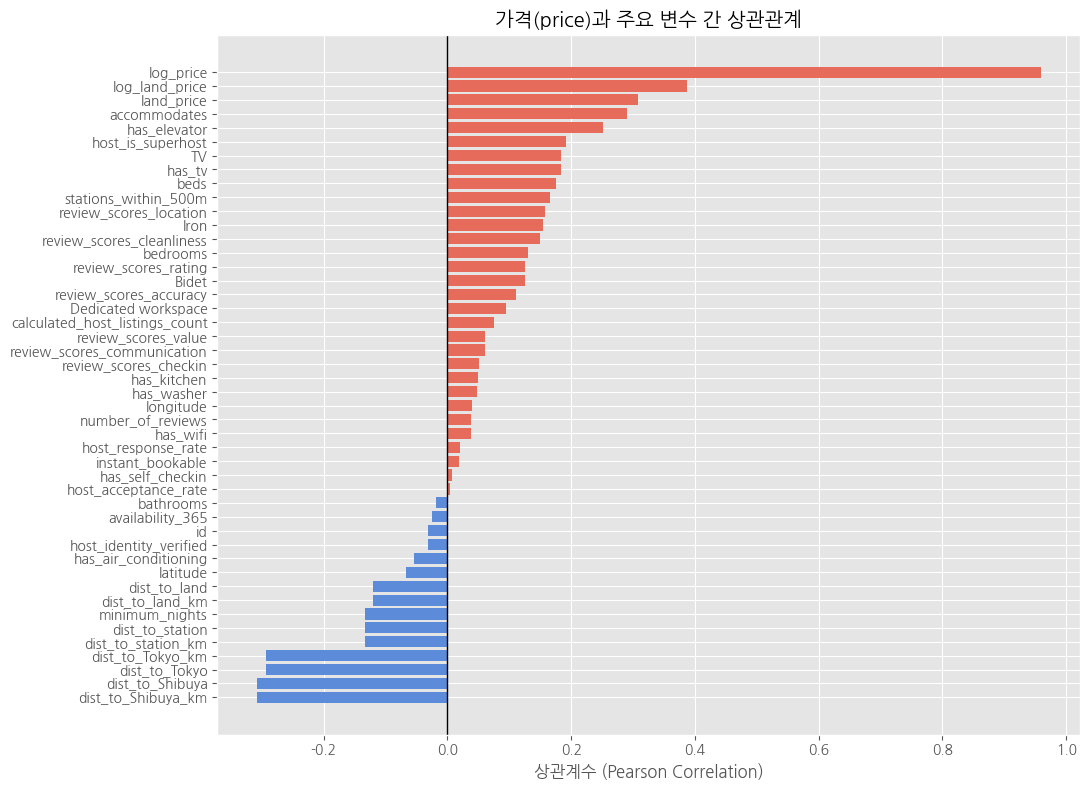

In [9]:
# ── 가격-변수 상관관계 바 ──
numeric_df = df.select_dtypes(include=['int64', 'float64']).copy()
corr_with_price = numeric_df.corr(numeric_only=True)['price'].drop('price').sort_values()

colors = ['#5B8BD9' if x < 0 else '#E66B5B' for x in corr_with_price.values]
plt.figure(figsize=(11, 8))
plt.barh(corr_with_price.index, corr_with_price.values, color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('상관계수 (Pearson Correlation)')
plt.title('가격(price)과 주요 변수 간 상관관계')
plt.tight_layout()
plt.savefig('result_03_price_correlation_bar.png', dpi=150)
plt.show()


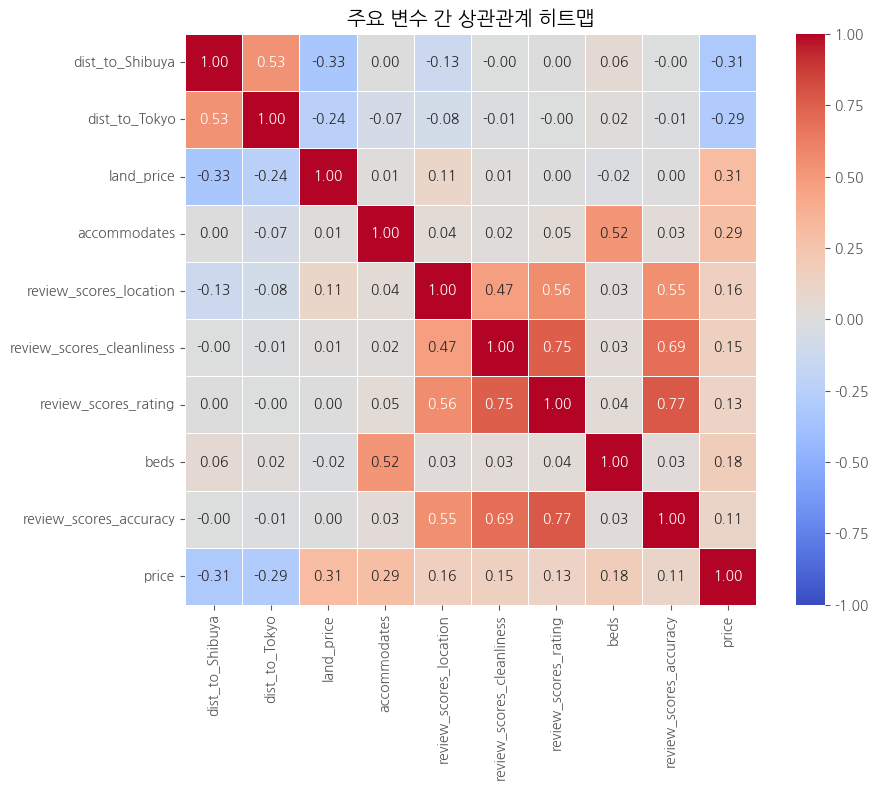

In [10]:
# ── 주요 변수 히트맵 ──
numeric_df = df.select_dtypes(include=['int64', 'float64']).copy()
heatmap_cols = [c for c in [
    'dist_to_Shibuya', 'dist_to_Tokyo', 'land_price', 'accommodates',
    'review_scores_location', 'review_scores_cleanliness', 'review_scores_rating',
    'beds', 'review_scores_accuracy', 'price'
] if c in numeric_df.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df[heatmap_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('주요 변수 간 상관관계 히트맵')
plt.tight_layout()
plt.savefig('result_04_price_correlation_heatmap.png', dpi=150)
plt.show()


슈퍼호스트 프리미엄: +19.9% (중앙값 기준)


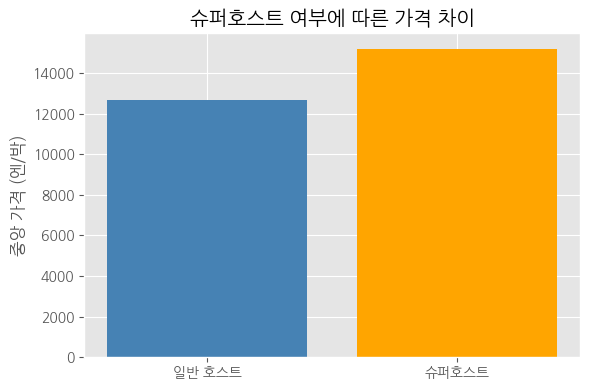

In [11]:
# ── 슈퍼호스트 효과 ──
median_super  = df[df['host_is_superhost'] == 1]['price'].median()
median_normal = df[df['host_is_superhost'] == 0]['price'].median()
premium = (median_super - median_normal) / median_normal * 100
print(f'슈퍼호스트 프리미엄: +{premium:.1f}% (중앙값 기준)')

plt.figure(figsize=(6, 4))
plt.bar(['일반 호스트', '슈퍼호스트'], [median_normal, median_super],
        color=['steelblue', 'orange'])
plt.ylabel('중앙 가격 (엔/박)')
plt.title('슈퍼호스트 여부에 따른 가격 차이')
plt.tight_layout()
plt.savefig('result_05_superhost_effect.png', dpi=150)
plt.show()


## 6. 역 접근성에 따른 가격 변화
내부스펙 고정 시뮬레이션 → 구간별 감가율 대시보드 → 중심지 프리미엄 · 역세권 프리미엄

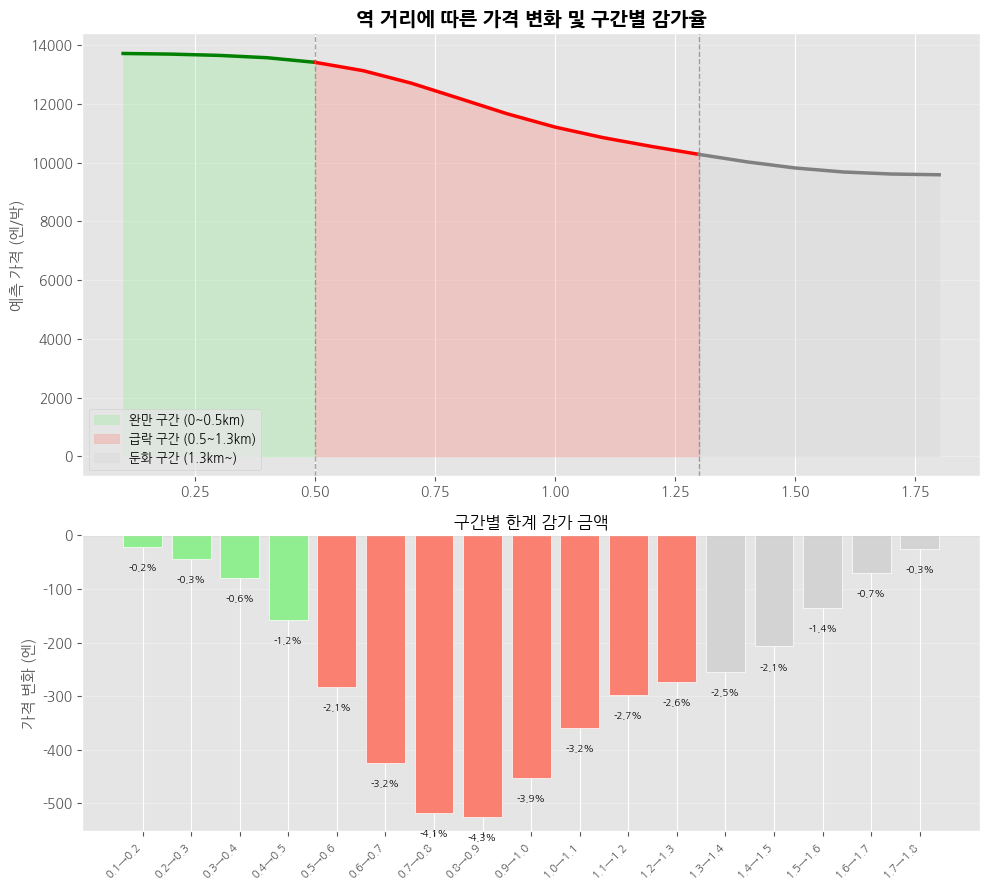


=== 구간별 요약 ===
완만 구간 (0.1~0.5km): -302엔 (-2.2%)
급락 구간 (0.5~1.3km): -3134엔 (-23.4%)
둔화 구간 (1.3km~): -693엔 (-6.7%)


In [12]:
# ── 역 거리별 예측 가격 시뮬레이션 ──
base_row = X_train[numeric_features].median().to_dict()
for col in categorical_features:
    if col in X_train.columns:
        base_row[col] = X_train[col].mode()[0]

dist_range  = np.arange(0.1, 1.9, 0.1)
pred_prices = []
for dist in dist_range:
    nearby = X_train[
        (X_train['dist_to_station_km'] >= dist - 0.2) &
        (X_train['dist_to_station_km'] <= dist + 0.2)
    ]
    if len(nearby) == 0:
        nearby = X_train
    row = base_row.copy()
    row['dist_to_station_km']  = dist
    row['log_land_price']      = nearby['log_land_price'].median()
    if 'stations_within_500m' in row:
        row['stations_within_500m'] = nearby['stations_within_500m'].median()
    if 'dist_to_Tokyo_km'    in row:
        row['dist_to_Tokyo_km']  = nearby['dist_to_Tokyo_km'].median()
    if 'dist_to_Shibuya_km'  in row:
        row['dist_to_Shibuya_km'] = nearby['dist_to_Shibuya_km'].median()
    pred_prices.append(np.expm1(best_pipe.predict(pd.DataFrame([row])[feature_cols])[0]))

smooth_prices = gaussian_filter1d(pred_prices, sigma=2)

# 자주 쓰는 수치 미리 계산
price_at_500m = smooth_prices[4]
price_at_1km  = smooth_prices[9]
price_diff    = price_at_500m - price_at_1km

# ── 구간별 감가율 대시보드 ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9), gridspec_kw={'height_ratios': [1.5, 1]})

zones = [
    (0,  4,  'lightgreen', '완만 구간 (0~0.5km)'),
    (4,  12, 'salmon',     '급락 구간 (0.5~1.3km)'),
    (12, len(dist_range)-1, 'lightgray', '둔화 구간 (1.3km~)'),
]
for start, end, color, label in zones:
    ax1.fill_between(dist_range[start:end+1], smooth_prices[start:end+1],
                     alpha=0.3, color=color, label=label)
    ax1.plot(dist_range[start:end+1], smooth_prices[start:end+1],
             color=color.replace('light','').replace('salmon','red'), linewidth=2.5)

for xv, txt, col in [(0.5,'완만→급락','gray'),(1.3,'급락→둔화','gray')]:
    ax1.axvline(x=xv, color=col, linestyle='--', linewidth=1, alpha=0.7)

ax1.set_ylabel('예측 가격 (엔/박)', fontsize=11)
ax1.set_title('역 거리에 따른 가격 변화 및 구간별 감가율', fontsize=14, fontweight='bold')
ax1.legend(loc='lower left', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

labels_b, diffs, colors_b = [], [], []
for i in range(1, len(dist_range)):
    d = smooth_prices[i] - smooth_prices[i-1]
    labels_b.append(f'{dist_range[i-1]:.1f}→{dist_range[i]:.1f}')
    diffs.append(d)
    colors_b.append('lightgreen' if i <= 4 else 'salmon' if i <= 12 else 'lightgray')

bars = ax2.bar(range(len(labels_b)), diffs, color=colors_b, edgecolor='white', linewidth=0.5)
for i, (bar, d) in enumerate(zip(bars, diffs)):
    rate = (d / smooth_prices[i]) * 100
    ax2.text(bar.get_x() + bar.get_width()/2, d - 30,
             f'{rate:+.1f}%', ha='center', va='top', fontsize=7)
ax2.set_xticks(range(len(labels_b)))
ax2.set_xticklabels(labels_b, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('가격 변화 (엔)', fontsize=11)
ax2.set_title('구간별 한계 감가 금액', fontsize=12)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('result_06_price_decay.png', dpi=150)
plt.show()

print('\n=== 구간별 요약 ===')
for label, start, end in [
    ('완만 구간 (0.1~0.5km)', 0, 4),
    ('급락 구간 (0.5~1.3km)', 4, 12),
    ('둔화 구간 (1.3km~)',    12, len(dist_range)-1),
]:
    total = smooth_prices[end] - smooth_prices[start]
    rate  = total / smooth_prices[start] * 100
    print(f'{label}: {total:+.0f}엔 ({rate:+.1f}%)')


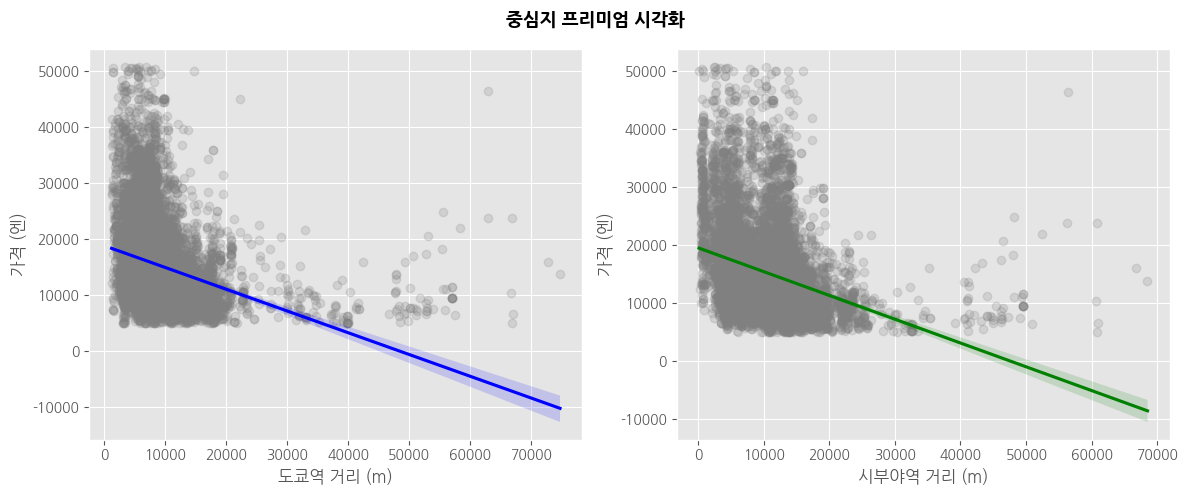

In [13]:
# ── 중심지 프리미엄 ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title, color in zip(
    axes,
    ['dist_to_Tokyo', 'dist_to_Shibuya'],
    ['도쿄역 거리 (m)', '시부야역 거리 (m)'],
    ['blue', 'green']
):
    sns.regplot(data=df, x=col, y='price', ax=ax,
                color=color, scatter_kws={'alpha': 0.2, 'color': 'gray'})
    ax.set_xlabel(title)
    ax.set_ylabel('가격 (엔)')
plt.suptitle('중심지 프리미엄 시각화', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('result_07_center_premium.png', dpi=150)
plt.show()


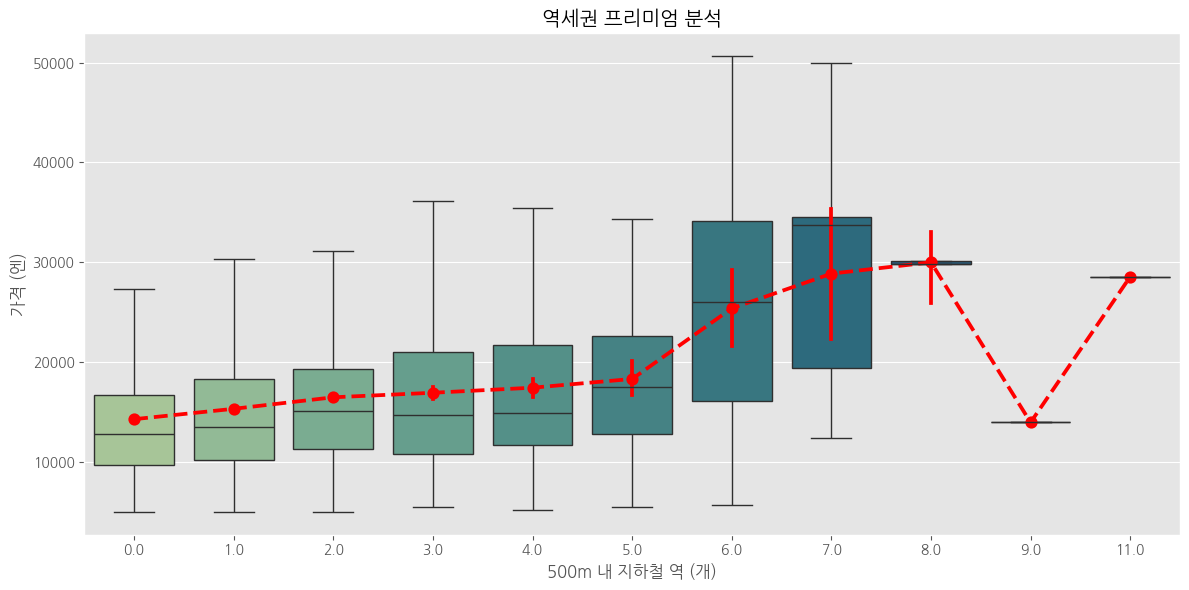

In [14]:
# ── 역세권 프리미엄 (500m 내 역 수) ──
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='stations_within_500m', y='price',
            hue='stations_within_500m', palette='crest', legend=False, showfliers=False)
sns.pointplot(data=df, x='stations_within_500m', y='price',
              estimator=np.mean, color='red', linestyles='--', markers='o')
plt.xlabel('500m 내 지하철 역 (개)')
plt.ylabel('가격 (엔)')
plt.title('역세권 프리미엄 분석')
plt.tight_layout()
plt.savefig('result_08_station_premium.png', dpi=150)
plt.show()


## 7. 공간 시각화 – 지역별 예측가격 지도

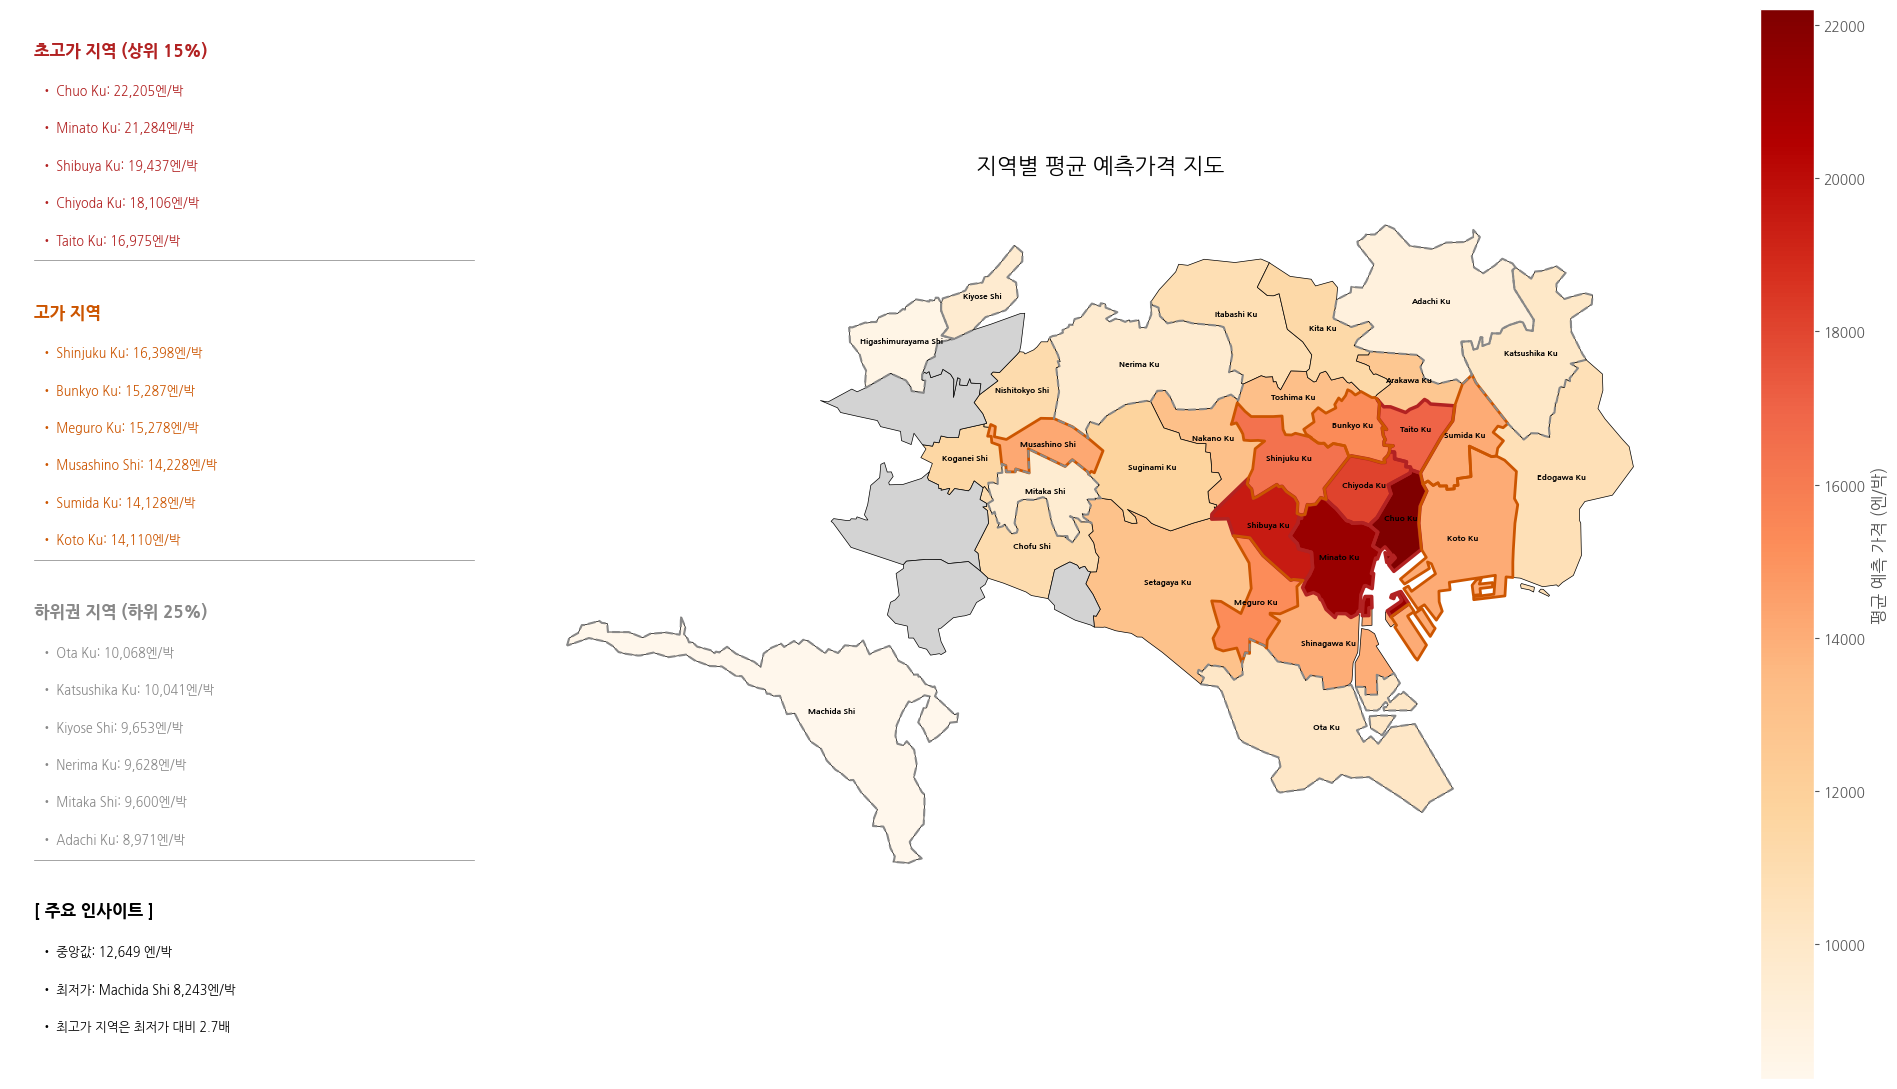

In [15]:
# ── 지도 데이터 로드 및 병합 ──
tokyo_map = gpd.read_file('neighbourhoods.geojson')
tokyo_map = tokyo_map.cx[139.5:139.95, 35.5:35.85]

map_df = X_test.copy()
map_df['pred_price'] = np.expm1(best_pipe.predict(X_test))
neigh_price = map_df.groupby('neighbourhood_cleansed')['pred_price'].mean().reset_index()

map_merged = tokyo_map.merge(
    neigh_price, left_on='neighbourhood', right_on='neighbourhood_cleansed', how='left')

# 동적 분위수 기준 그룹 분류
q85 = map_merged['pred_price'].quantile(0.85)
q65 = map_merged['pred_price'].quantile(0.65)
q25 = map_merged['pred_price'].quantile(0.25)

def classify_dynamic(price):
    if pd.isna(price):   return None
    elif price >= q85:   return '초고가'
    elif price >= q65:   return '고가'
    elif price >= q25:   return '중위권'
    else:                return '하위권'

map_merged['group'] = map_merged['pred_price'].apply(classify_dynamic)
top3    = map_merged[map_merged['group']=='초고가'].sort_values('pred_price', ascending=False).reset_index(drop=True)
high    = map_merged[map_merged['group']=='고가'].sort_values('pred_price', ascending=False).reset_index(drop=True)
low     = map_merged[map_merged['group']=='하위권'].sort_values('pred_price', ascending=False).reset_index(drop=True)
bottom1 = map_merged.nsmallest(1, 'pred_price').reset_index(drop=True)
median_price = int(map_merged['pred_price'].median())

# ── 대시보드 출력 ──
fig, (ax_text, ax_map) = plt.subplots(1, 2, figsize=(20, 11),
                                       gridspec_kw={'width_ratios': [1, 3]})
ax_text.axis('off')
y_pos = 0.97

def print_group(ax, y_pos, title, color, data, n=6):
    ax.text(0.05, y_pos, title, fontsize=12, fontweight='bold',
            color=color, transform=ax.transAxes, va='top')
    y_pos -= 0.04
    for _, row in data.head(n).iterrows():
        ax.text(0.05, y_pos, f"  • {row['neighbourhood']}: {int(row['pred_price']):,}엔/박",
                fontsize=9, color=color, transform=ax.transAxes, va='top')
        y_pos -= 0.035
    y_pos -= 0.01
    ax.axhline(y=y_pos+0.02, xmin=0.05, xmax=0.95, color='gray', linewidth=0.5)
    return y_pos - 0.02

y_pos = print_group(ax_text, y_pos, '초고가 지역 (상위 15%)', '#b22222', top3)
y_pos = print_group(ax_text, y_pos, '고가 지역', '#cc5500', high)
y_pos = print_group(ax_text, y_pos, '하위권 지역 (하위 25%)', '#888888', low)

ax_text.text(0.05, y_pos, '[ 주요 인사이트 ]', fontsize=12, fontweight='bold',
             transform=ax_text.transAxes, va='top')
y_pos -= 0.04
ax_text.text(0.05, y_pos, f'  • 중앙값: {median_price:,} 엔/박',
             fontsize=9, transform=ax_text.transAxes, va='top')
y_pos -= 0.035
if len(bottom1) > 0:
    ax_text.text(0.05, y_pos,
                 f"  • 최저가: {bottom1.iloc[0]['neighbourhood']} {int(bottom1.iloc[0]['pred_price']):,}엔/박",
                 fontsize=9, transform=ax_text.transAxes, va='top')
    y_pos -= 0.035
if len(top3) > 0 and len(bottom1) > 0:
    ratio = top3.iloc[0]['pred_price'] / bottom1.iloc[0]['pred_price']
    ax_text.text(0.05, y_pos,
                 f'  • 최고가 지역은 최저가 대비 {ratio:.1f}배',
                 fontsize=9, transform=ax_text.transAxes, va='top')

map_merged.plot(column='pred_price', cmap='OrRd', legend=True,
                linewidth=0.5, edgecolor='black',
                missing_kwds={'color': 'lightgrey', 'label': '데이터 없음'},
                legend_kwds={'label': '평균 예측 가격 (엔/박)', 'orientation': 'vertical'},
                ax=ax_map)

for _, row in map_merged.iterrows():
    if row.geometry is not None and not pd.isna(row['pred_price']):
        ax_map.annotate(row['neighbourhood'],
            xy=(row.geometry.centroid.x, row.geometry.centroid.y),
            fontsize=6, ha='center', color='black', weight='bold')

if len(top3)  > 0: top3.plot(ax=ax_map, color='none', edgecolor='#b22222', linewidth=2.5)
if len(high)  > 0: high.plot(ax=ax_map, color='none', edgecolor='#cc5500', linewidth=2)
if len(low)   > 0: low.plot(ax=ax_map,  color='none', edgecolor='#888888', linewidth=1.5, linestyle='--')

ax_map.set_title('지역별 평균 예측가격 지도', fontsize=16, pad=15)
ax_map.axis('off')
plt.tight_layout()
plt.savefig('map_final.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. 호스트 전략 분석
내부스펙 가격 기여도 · 핵심 변수 종합 요약 · 편의시설 투자 효율 · 스위트스팟 전략 · 종합 전략

In [16]:
# ── 공통 수치 계산 ──
entire_price  = df[df['room_type']=='Entire home/apt']['price'].median()
private_price = df[df['room_type']=='Private room']['price'].median()
room_diff     = int(entire_price - private_price)
p2 = df[df['accommodates']==2]['price'].median()
p3 = df[df['accommodates']==3]['price'].median()
p4 = df[df['accommodates']==4]['price'].median()
b1 = df[df['bedrooms']==1]['price'].median()
b2 = df[df['bedrooms']==2]['price'].median()
bedroom_diff  = int(b2 - b1)

tv_diff    = int(df[df['TV']==1]['price'].median()                  - df[df['TV']==0]['price'].median())
iron_diff  = int(df[df['Iron']==1]['price'].median()                - df[df['Iron']==0]['price'].median())
ws_diff    = int(df[df['Dedicated workspace']==1]['price'].median() - df[df['Dedicated workspace']==0]['price'].median())
bidet_diff = int(df[df['Bidet']==1]['price'].median()               - df[df['Bidet']==0]['price'].median())

prop_price = (df[df['property_type'].isin([
    'Entire rental unit','Entire condo','Entire home','Private room in home','Private room in ryokan'
])].groupby('property_type')['price'].median())
rental     = prop_price.get('Entire rental unit', 0)
condo      = prop_price.get('Entire condo', 0)
condo_diff = int(condo - rental)

print('수치 계산 완료')


수치 계산 완료


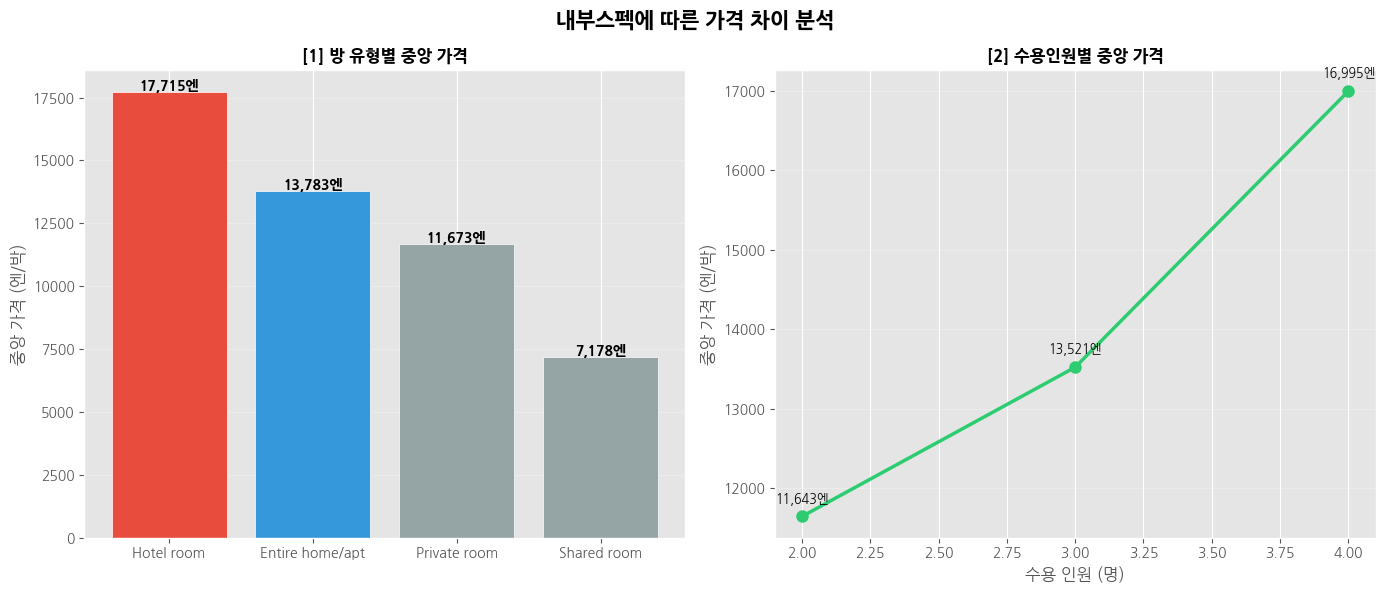

In [17]:
# ── 방 유형 / 수용인원별 가격 ──
room_price  = df.groupby('room_type')['price'].median().sort_values(ascending=False)
accom_price = df.groupby('accommodates')['price'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('내부스펙에 따른 가격 차이 분석', fontsize=15, fontweight='bold')

colors_r = ['#e74c3c' if i == 0 else '#3498db' if i == 1 else '#95a5a6' for i in range(len(room_price))]
bars_r = axes[0].bar(room_price.index, room_price.values, color=colors_r, edgecolor='white')
for bar, val in zip(bars_r, room_price.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 100, f'{int(val):,}엔',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('[1] 방 유형별 중앙 가격', fontsize=12, fontweight='bold')
axes[0].set_ylabel('중앙 가격 (엔/박)')
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(accom_price.index, accom_price.values, marker='o', color='#2ecc71', linewidth=2.5, markersize=8)
for x, yv in zip(accom_price.index, accom_price.values):
    axes[1].annotate(f'{int(yv):,}엔', xy=(x, yv), xytext=(0, 10),
                     textcoords='offset points', ha='center', fontsize=9)
axes[1].set_title('[2] 수용인원별 중앙 가격', fontsize=12, fontweight='bold')
axes[1].set_ylabel('중앙 가격 (엔/박)')
axes[1].set_xlabel('수용 인원 (명)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('result_09_internal_spec.png', dpi=150)
plt.show()


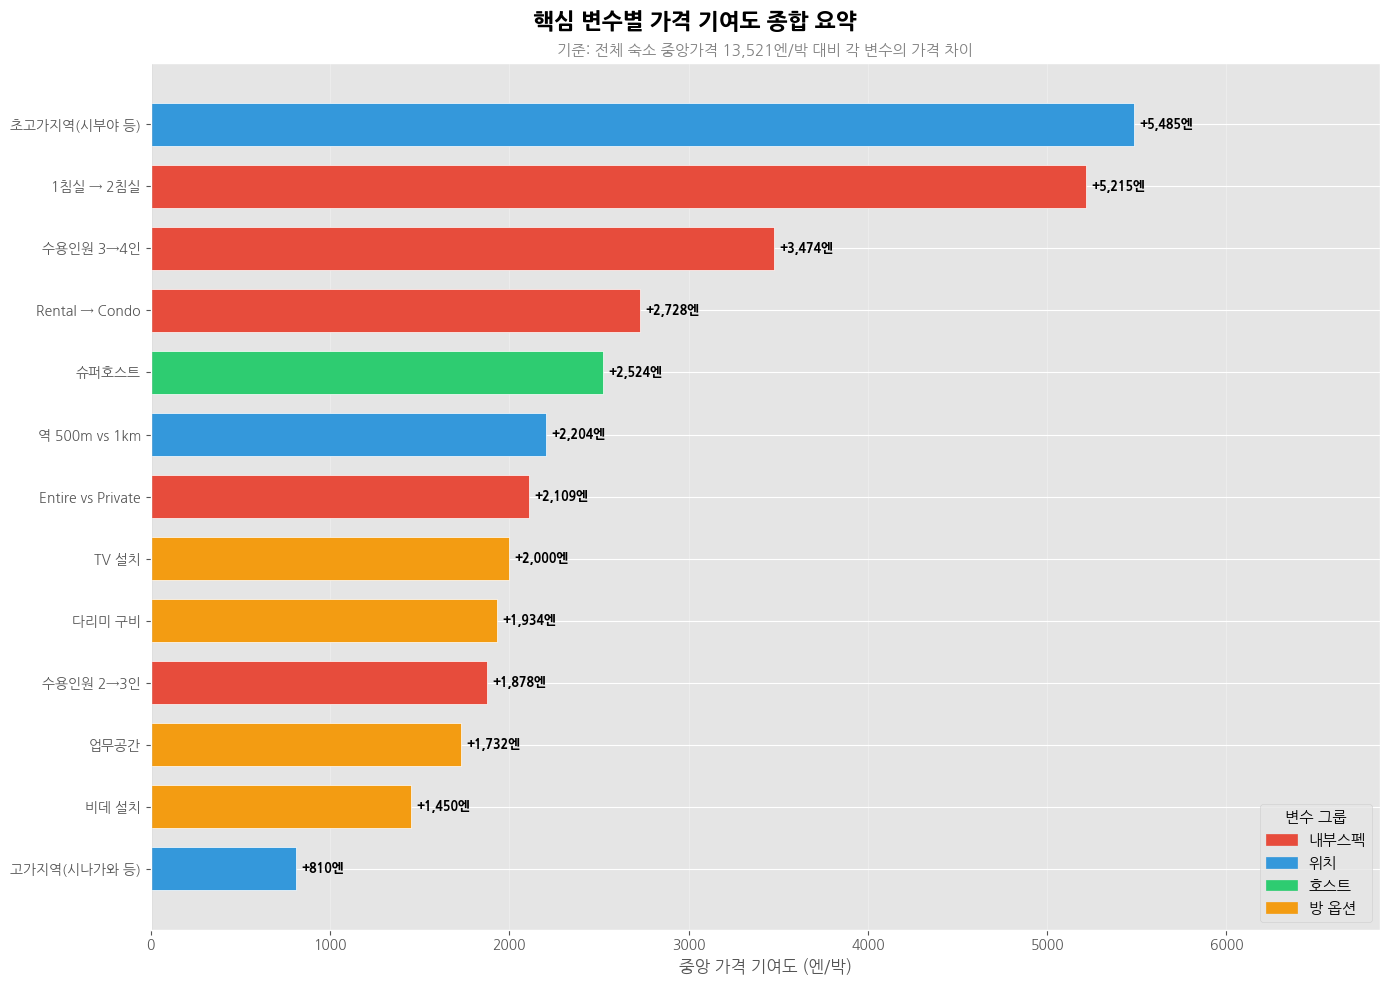

In [18]:
# ── 핵심 변수 가격 기여도 종합 요약 ──
categories = {
    '내부스펙': {
        'color': '#e74c3c',
        'items': [
            ('1침실 → 2침실', bedroom_diff),
            ('수용인원 3→4인', int(p4 - p3)),
            ('Entire vs Private', room_diff),
            ('수용인원 2→3인', int(p3 - p2)),
            ('Rental → Condo', condo_diff),
        ]
    },
    '위치': {
        'color': '#3498db',
        'items': [
            ('초고가지역(시부야 등)', 19832 - 14347),
            ('역 500m vs 1km', int(price_diff)),
            ('고가지역(시나가와 등)', 15157 - 14347),
        ]
    },
    '호스트': {
        'color': '#2ecc71',
        'items': [('슈퍼호스트', int(median_super - median_normal))]
    },
    '방 옵션': {
        'color': '#f39c12',
        'items': [
            ('TV 설치', tv_diff), ('다리미 구비', iron_diff),
            ('업무공간', ws_diff), ('비데 설치', bidet_diff),
        ]
    },
}

all_items = sorted(
    [{'label': lbl, 'value': val, 'color': info['color'], 'cat': cat}
     for cat, info in categories.items() for lbl, val in info['items']],
    key=lambda x: x['value']
)

fig, ax = plt.subplots(figsize=(14, 10))
fig.suptitle('핵심 변수별 가격 기여도 종합 요약', fontsize=16, fontweight='bold', y=0.98)

bars = ax.barh(
    [i['label'] for i in all_items], [i['value'] for i in all_items],
    color=[i['color'] for i in all_items], edgecolor='white', height=0.7)
for bar, item in zip(bars, all_items):
    ax.text(item['value'] + 30, bar.get_y() + bar.get_height()/2,
            f"+{item['value']:,}엔", va='center', ha='left', fontsize=9, fontweight='bold')

legend_patches = [mpatches.Patch(color=info['color'], label=cat) for cat, info in categories.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=11, title='변수 그룹', title_fontsize=11)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('중앙 가격 기여도 (엔/박)', fontsize=12)
ax.set_title(f'기준: 전체 숙소 중앙가격 {int(df["price"].median()):,}엔/박 대비 각 변수의 가격 차이',
             fontsize=11, color='gray')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(i['value'] for i in all_items) * 1.25)
plt.tight_layout()
plt.savefig('result_10_summary_contribution.png', dpi=150, bbox_inches='tight')
plt.show()


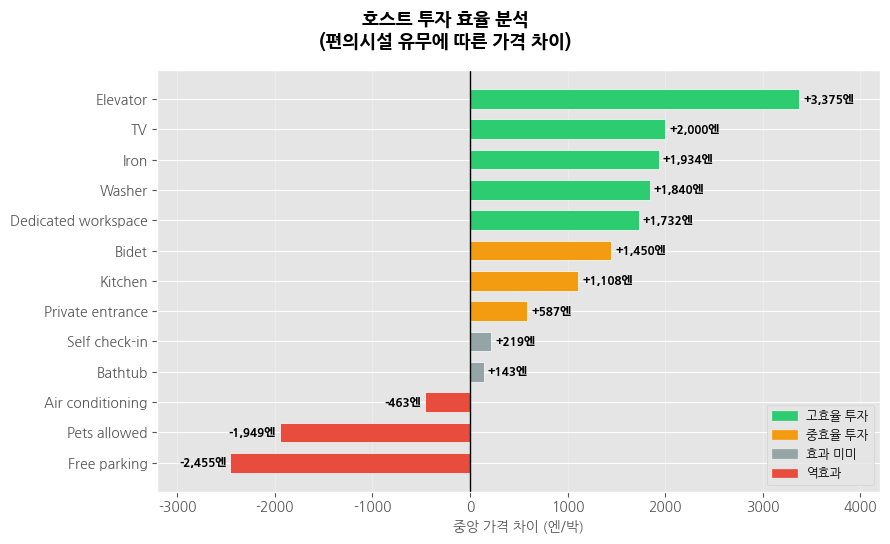

In [19]:
# ── 편의시설 투자 효율 ──
amenity_items = ['Free parking','Pets allowed','Air conditioning','Bathtub','Self check-in',
                 'Private entrance','Kitchen','Bidet','Dedicated workspace','Washer','Iron','TV','Elevator']
amenity_vals  = [-2455,-1949,-463,143,219,587,1108,1450,1732,1840,1934,2000,3375]
amenity_cols  = ['#e74c3c']*3 + ['#95a5a6']*2 + ['#f39c12']*3 + ['#2ecc71']*5

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.suptitle('호스트 투자 효율 분석\n(편의시설 유무에 따른 가격 차이)', fontsize=13, fontweight='bold')
bars_a = ax.barh(amenity_items, amenity_vals, color=amenity_cols, edgecolor='white', height=0.65)
for bar, val in zip(bars_a, amenity_vals):
    xp = val + 40 if val >= 0 else val - 40
    ha = 'left' if val >= 0 else 'right'
    ax.text(xp, bar.get_y() + bar.get_height()/2,
            f'{val:+,}엔', va='center', ha=ha, fontsize=8.5, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('중앙 가격 차이 (엔/박)', fontsize=10)
ax.set_xlim(-3200, 4200)
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)
legend_a = [
    mpatches.Patch(color='#2ecc71', label='고효율 투자'),
    mpatches.Patch(color='#f39c12', label='중효율 투자'),
    mpatches.Patch(color='#95a5a6', label='효과 미미'),
    mpatches.Patch(color='#e74c3c', label='역효과'),
]
ax.legend(handles=legend_a, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('result_11_host_investment.png', dpi=150, bbox_inches='tight')
plt.show()


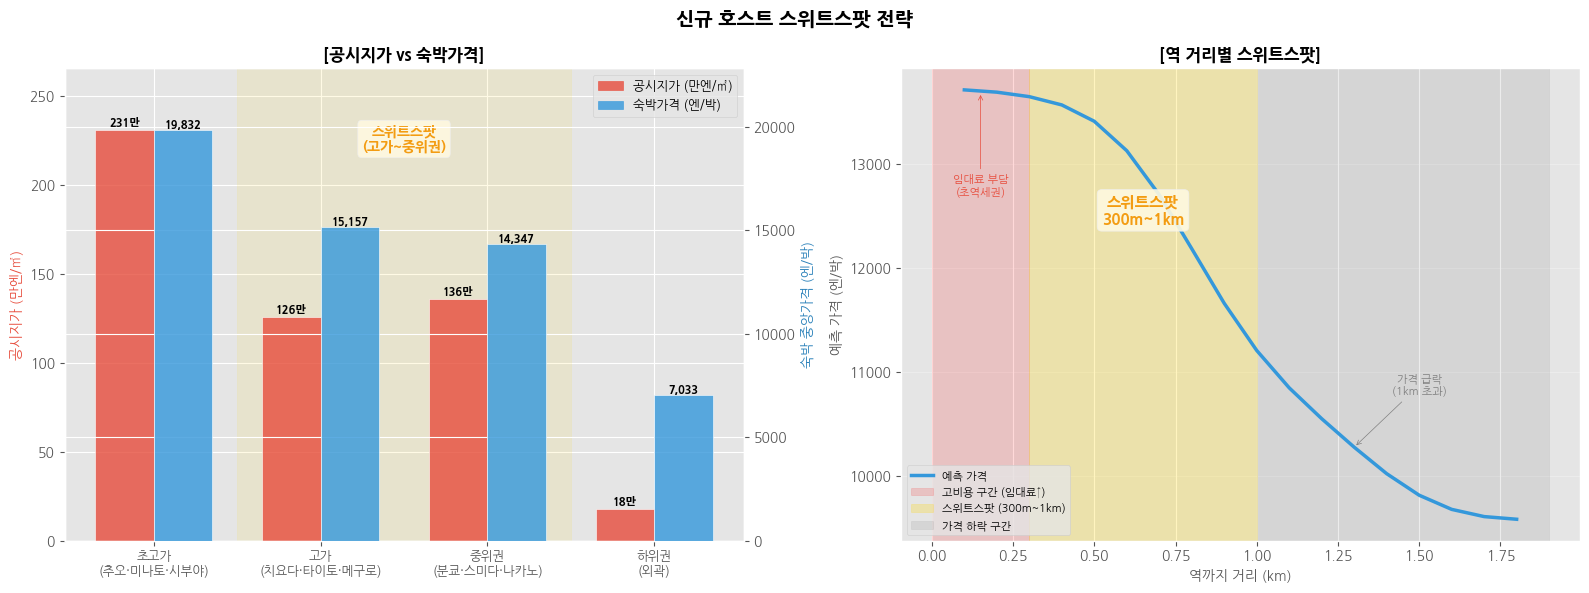

In [29]:
# ── 스위트스팟 전략 ──
fig, (ax_land, ax_sta) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('신규 호스트 스위트스팟 전략', fontsize=14, fontweight='bold')

regions = ['초고가\n(추오·미나토·시부야)', '고가\n(치요다·타이토·메구로)', '중위권\n(분쿄·스미다·나카노)', '하위권\n(외곽)']
land_prices_v   = [231, 126, 136, 18]
rental_prices_v = [19832, 15157, 14347, 7033]
x_idx = np.arange(len(regions))
width = 0.35
ax_twin = ax_land.twinx()
ax_land.set_axisbelow(True); ax_twin.set_axisbelow(True)
bl = ax_land.bar(x_idx - width/2, land_prices_v, width, color='#e74c3c', alpha=0.8, edgecolor='white', zorder=3)
br = ax_twin.bar(x_idx + width/2, rental_prices_v, width, color='#3498db', alpha=0.8, edgecolor='white', zorder=3)
for bar, val in zip(bl, land_prices_v):
    ax_land.text(bar.get_x()+bar.get_width()/2, val+2, f'{val}만', ha='center', fontsize=8, fontweight='bold', zorder=5)
for bar, val in zip(br, rental_prices_v):
    ax_twin.text(bar.get_x()+bar.get_width()/2, val+100, f'{val:,}', ha='center', fontsize=8, fontweight='bold', zorder=5)
ax_land.set_ylim(0, max(land_prices_v) * 1.15); ax_twin.set_ylim(0, max(rental_prices_v) * 1.15)
ax_land.set_xticks(x_idx); ax_land.set_xticklabels(regions, fontsize=9)
ax_land.set_ylabel('공시지가 (만엔/㎡)', fontsize=10, color='#e74c3c')
ax_twin.set_ylabel('숙박 중앙가격 (엔/박)', fontsize=10, color='#2980b9')
ax_land.axvspan(0.5, 2.5, alpha=0.1, color='gold')  # 고가~중위권까지 확장
ax_land.text(1.5, max(land_prices_v)*0.95, '스위트스팟\n(고가~중위권)', ha='center', fontsize=10,
             fontweight='bold', color='#f39c12',
             bbox=dict(boxstyle='round', facecolor='#fff9e0', alpha=0.9), zorder=5)
ax_land.legend(handles=[
    mpatches.Patch(color='#e74c3c', alpha=0.8, label='공시지가 (만엔/㎡)'),
    mpatches.Patch(color='#3498db', alpha=0.8, label='숙박가격 (엔/박)')
], loc='upper right', fontsize=9)
ax_land.set_title('[공시지가 vs 숙박가격]', fontsize=12, fontweight='bold')

# 역 거리 스위트스팟
ax_sta.plot(dist_range, smooth_prices, color='#3498db', linewidth=2.5, label='예측 가격')
ax_sta.axvspan(0.0, 0.3, alpha=0.15, color='red',  label='고비용 구간 (임대료↑)')
ax_sta.axvspan(0.3, 1.0, alpha=0.25, color='gold', label='스위트스팟 (300m~1km)')
ax_sta.axvspan(1.0, 1.9, alpha=0.15, color='gray', label='가격 하락 구간')
mid = (smooth_prices[2] + smooth_prices[9]) / 2
ax_sta.annotate('스위트스팟\n300m~1km', xy=(0.65, mid), fontsize=11, fontweight='bold',
                color='#f39c12', ha='center',
                bbox=dict(boxstyle='round', facecolor='#fff9e0', alpha=0.9))
ax_sta.annotate('임대료 부담\n(초역세권)', xy=(0.15, smooth_prices[1]),
                xytext=(0.15, smooth_prices[1]-1000), fontsize=8, color='#e74c3c', ha='center',
                arrowprops=dict(arrowstyle='->', color='#e74c3c'))
ax_sta.annotate('가격 급락\n(1km 초과)', xy=(1.3, smooth_prices[12]),
                xytext=(1.5, smooth_prices[12]+500), fontsize=8, color='gray', ha='center',
                arrowprops=dict(arrowstyle='->', color='gray'))
ax_sta.set_xlabel('역까지 거리 (km)', fontsize=10)
ax_sta.set_ylabel('예측 가격 (엔/박)', fontsize=10)
ax_sta.legend(fontsize=8, loc='lower left')
ax_sta.grid(axis='y', alpha=0.3)
ax_sta.set_title('[역 거리별 스위트스팟]', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('result_12_sweetspot.png', dpi=150, bbox_inches='tight')
plt.show()


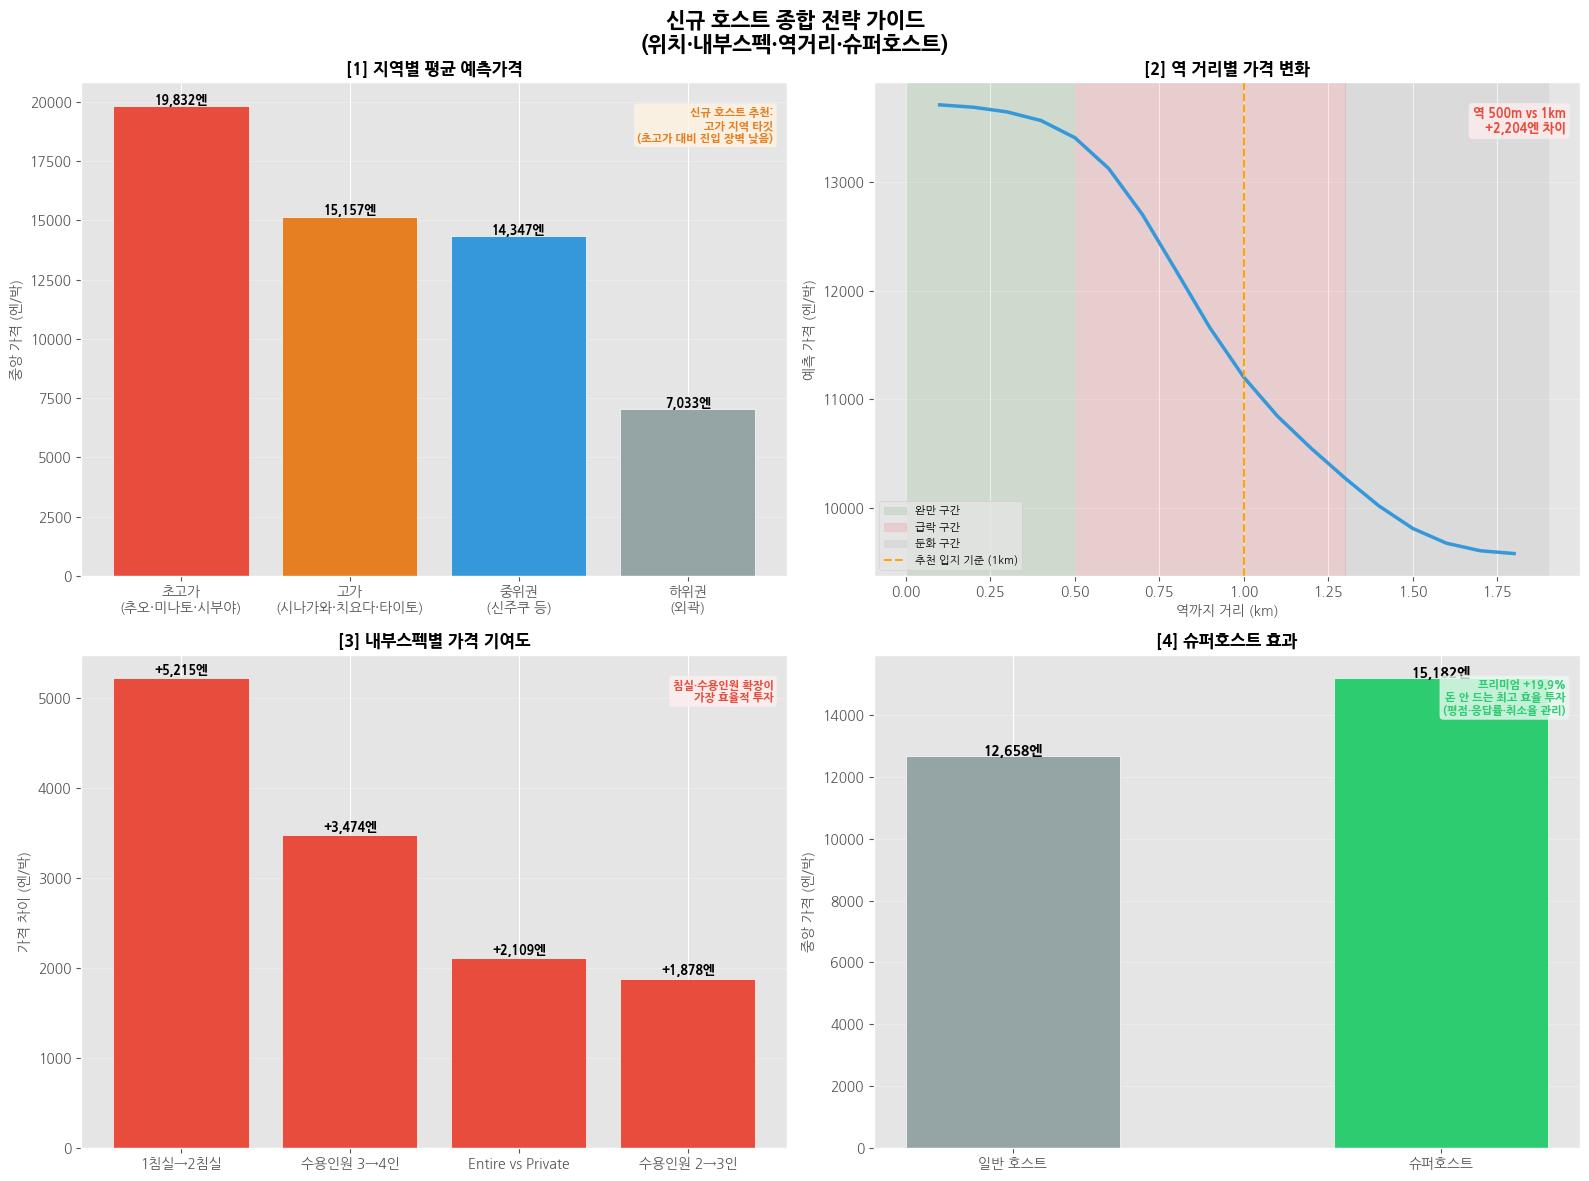

In [21]:
# ── 종합 전략 4-panel ──
region_groups = {
    '초고가\n(추오·미나토·시부야)': 19832,
    '고가\n(시나가와·치요다·타이토)': 15157,
    '중위권\n(신주쿠 등)': 14347,
    '하위권\n(외곽)': 7033,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('신규 호스트 종합 전략 가이드\n(위치·내부스펙·역거리·슈퍼호스트)',
             fontsize=15, fontweight='bold')

ax1 = axes[0, 0]
b1 = ax1.bar(region_groups.keys(), region_groups.values(),
             color=['#e74c3c','#e67e22','#3498db','#95a5a6'], edgecolor='white')
for bar, val in zip(b1, region_groups.values()):
    ax1.text(bar.get_x()+bar.get_width()/2, val+100, f'{val:,}엔', ha='center', fontsize=9, fontweight='bold')
ax1.set_title('[1] 지역별 평균 예측가격', fontsize=12, fontweight='bold')
ax1.set_ylabel('중앙 가격 (엔/박)', fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.text(0.98, 0.95, '신규 호스트 추천:\n고가 지역 타깃\n(초고가 대비 진입 장벽 낮음)',
         transform=ax1.transAxes, fontsize=8, ha='right', va='top', color='#e67e22', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='#fff3e0', alpha=0.8))

ax2 = axes[0, 1]
ax2.plot(dist_range, smooth_prices, color='#3498db', linewidth=2.5)
for s, e, c, lbl in [(0, 0.5, 'green', '완만 구간'), (0.5, 1.3, 'red', '급락 구간'), (1.3, 1.9, 'gray', '둔화 구간')]:
    ax2.axvspan(s, e, alpha=0.1, color=c, label=lbl)
ax2.axvline(x=1.0, color='orange', linestyle='--', linewidth=1.5, label='추천 입지 기준 (1km)')
ax2.set_title('[2] 역 거리별 가격 변화', fontsize=12, fontweight='bold')
ax2.set_xlabel('역까지 거리 (km)', fontsize=10)
ax2.set_ylabel('예측 가격 (엔/박)', fontsize=10)
ax2.legend(fontsize=8, loc='lower left')
ax2.grid(axis='y', alpha=0.3)
ax2.text(0.98, 0.95, f'역 500m vs 1km\n{int(price_diff):+,}엔 차이',
         transform=ax2.transAxes, fontsize=9, ha='right', va='top', color='#e74c3c', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='#ffeeee', alpha=0.8))

ax3 = axes[1, 0]
spec_items = [
    ('1침실→2침실', bedroom_diff), ('수용인원 3→4인', int(p4-p3)),
    ('Entire vs Private', room_diff), ('수용인원 2→3인', int(p3-p2))
]
b3 = ax3.bar([x[0] for x in spec_items], [x[1] for x in spec_items],
             color='#e74c3c', edgecolor='white')
for bar, val in zip(b3, [x[1] for x in spec_items]):
    ax3.text(bar.get_x()+bar.get_width()/2, val+50, f'+{val:,}엔',
             ha='center', fontsize=9, fontweight='bold')
ax3.set_title('[3] 내부스펙별 가격 기여도', fontsize=12, fontweight='bold')
ax3.set_ylabel('가격 차이 (엔/박)', fontsize=10)
ax3.grid(axis='y', alpha=0.3)
ax3.text(0.98, 0.95, '침실·수용인원 확장이\n가장 효율적 투자',
         transform=ax3.transAxes, fontsize=8, ha='right', va='top', color='#e74c3c', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='#ffeeee', alpha=0.8))

ax4 = axes[1, 1]
b4 = ax4.bar(['일반 호스트', '슈퍼호스트'], [int(median_normal), int(median_super)],
             color=['#95a5a6','#2ecc71'], edgecolor='white', width=0.5)
for bar, val in zip(b4, [int(median_normal), int(median_super)]):
    ax4.text(bar.get_x()+bar.get_width()/2, val+50, f'{val:,}엔',
             ha='center', fontsize=10, fontweight='bold')
ax4.set_title('[4] 슈퍼호스트 효과', fontsize=12, fontweight='bold')
ax4.set_ylabel('중앙 가격 (엔/박)', fontsize=10)
ax4.grid(axis='y', alpha=0.3)
ax4.text(0.98, 0.95, f'프리미엄 +{premium:.1f}%\n돈 안 드는 최고 효율 투자\n(평점·응답률·취소율 관리)',
         transform=ax4.transAxes, fontsize=8, ha='right', va='top', color='#2ecc71', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='#eafaf1', alpha=0.8))

plt.tight_layout()
plt.savefig('result_13_host_strategy_final.png', dpi=150)
plt.show()


## 9. 역 거리별 공시지가 대비 수익 효율 분석
역으로부터 멀어질수록 공시지가는 급락하지만 숙박비는 완만하게 하락한다. 효율 지수가 높을수록 매입 효율이 좋은 구간이다.

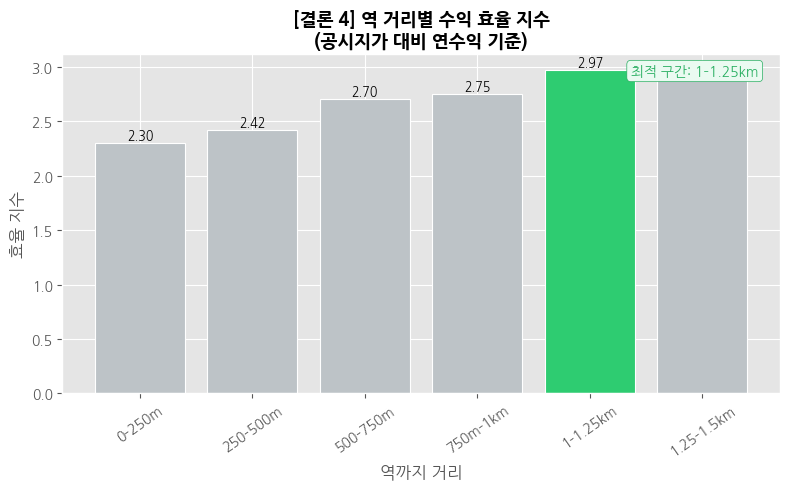


★ 호스트 최적 매입 구간: [1–1.25km]
      zone    n    ratio
    0–250m 2285 2.303769
  250–500m 5099 2.418568
  500–750m 3144 2.703258
  750m–1km 1044 2.753367
  1–1.25km  207 2.969014
1.25–1.5km   54 2.928474


In [22]:
# ── 역 거리 구간별 공시지가 대비 수익 효율 분석 ──
bins_z   = [0, 250, 500, 750, 1000, 1250, 1500, 99999]
labels_z = ['0–250m', '250–500m', '500–750m', '750m–1km',
            '1–1.25km', '1.25–1.5km', '1.5km+']
df['zone'] = pd.cut(df['dist_to_station'], bins=bins_z, labels=labels_z)

df['_occ']         = (365 - df['availability_365']) / 365
df['_monthly_rev'] = df['price'] * df['_occ'] * 30
df['_ratio']       = df['_monthly_rev'] * 12 / df['land_price']

df_z = df[df['_ratio'] < df['_ratio'].quantile(0.99)]

z = df_z.groupby('zone', observed=True).agg(
    n     = ('price',  'count'),
    ratio = ('_ratio', 'mean'),
).reset_index()
z = z[z['n'] >= 50].reset_index(drop=True)

best_idx   = z['ratio'].idxmax()
best_zone  = z.loc[best_idx, 'zone']
bar_colors = ['#2ecc71' if i == best_idx else '#bdc3c7' for i in range(len(z))]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(z['zone'], z['ratio'], color=bar_colors, edgecolor='white', linewidth=0.8)
ax.set_title('[결론 4] 역 거리별 수익 효율 지수\n(공시지가 대비 연수익 기준)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('효율 지수')
ax.set_xlabel('역까지 거리')
ax.tick_params(axis='x', rotation=35)
for bar, val in zip(bars, z['ratio']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)
ax.annotate(f'최적 구간: {best_zone}', xy=(0.97, 0.97), xycoords='axes fraction',
            ha='right', va='top', fontsize=10, color='#27ae60',
            bbox=dict(boxstyle='round,pad=0.3', fc='#eafaf1', ec='#27ae60'))

plt.tight_layout()
plt.savefig('result_16_land_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n★ 호스트 최적 매입 구간: [{best_zone}]')
print(z[['zone', 'n', 'ratio']].to_string(index=False))


##  (부록) 가격 구간 분류 모델
저가/중가/고가 3구간 RandomForest Classifier — 본 분석과 독립적인 참고용 섹션

아웃라이어 제거: 619개 → 남은 데이터: 11358개

구간별 분포:
price_group
중가    6071
고가    3592
저가    1695
Name: count, dtype: int64

정확도: 75.75%
              precision    recall  f1-score   support

          저가       0.80      0.42      0.55       339
          중가       0.72      0.91      0.80      1214
          고가       0.85      0.66      0.75       719

    accuracy                           0.76      2272
   macro avg       0.79      0.66      0.70      2272
weighted avg       0.77      0.76      0.75      2272



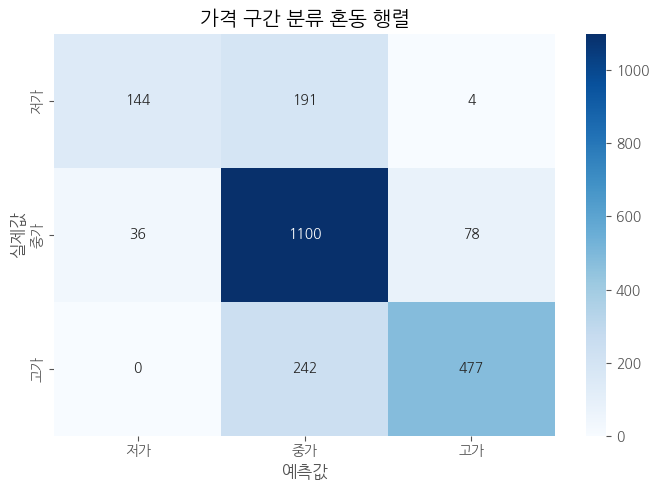

In [26]:
# ── 가격 구간 라벨 생성 ──
q25_clf = df['price'].quantile(0.25)
q75_clf = df['price'].quantile(0.75)
iqr_clf = q75_clf - q25_clf
df_clf  = df[df['price'] <= q75_clf + 1.5 * iqr_clf].copy()
print(f'아웃라이어 제거: {len(df) - len(df_clf)}개 → 남은 데이터: {len(df_clf)}개')

def price_label(price):
    if price < 9000:   return 0  # 저가
    elif price < 16000: return 1  # 중가
    else:               return 2  # 고가

df_clf['price_group'] = df_clf['price'].apply(price_label)
print('\n구간별 분포:')
print(df_clf['price_group'].map({0:'저가',1:'중가',2:'고가'}).value_counts())

# ── 학습 ──
X_clf = df_clf[[c for c in feature_cols if c in df_clf.columns]].select_dtypes(include=['number']).copy()
y_clf = df_clf['price_group']
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

rf_clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_clf.fit(X_tr_c, y_tr_c)
y_pred_c = rf_clf.predict(X_te_c)

print(f'\n정확도: {accuracy_score(y_te_c, y_pred_c)*100:.2f}%')
print(classification_report(y_te_c, y_pred_c, target_names=['저가','중가','고가']))

# ── 혼동 행렬 ──
cm = confusion_matrix(y_te_c, y_pred_c)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['저가','중가','고가'], yticklabels=['저가','중가','고가'])
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.title('가격 구간 분류 혼동 행렬')
plt.tight_layout()
plt.savefig('result_15_clf_confusion_matrix.png', dpi=150)
plt.show()


## [부록] 신주쿠 포함 데이터 상관관계 히트맵

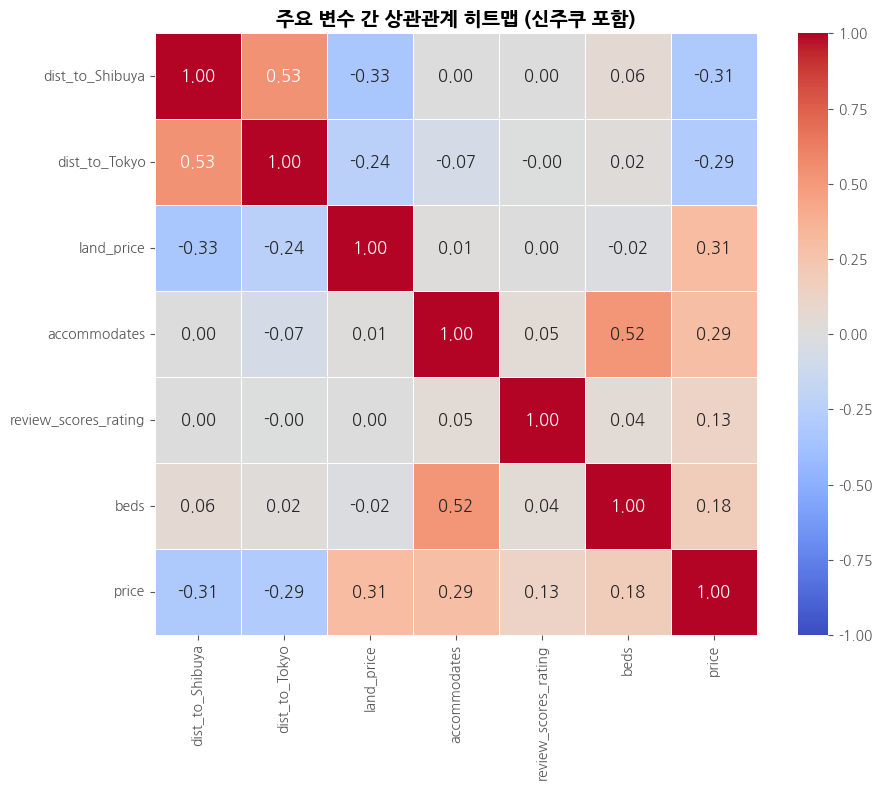

In [27]:
# ============================================================
# [부록] 신주쿠 포함 데이터 상관관계 히트맵
# ============================================================

df_with = pd.read_csv("final_airbnb.csv")

def clean_price(df):
    df = df.copy()
    df['price'] = (
        df['price'].astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
    )
    lower = df['price'].quantile(0.01)
    upper = df['price'].quantile(0.99)
    return df[(df['price'] >= lower) & (df['price'] <= upper)].copy()

df_with = clean_price(df_with)

heatmap_cols = [
    'dist_to_Shibuya', 'dist_to_Tokyo', 'land_price',
    'accommodates', 'review_scores_rating', 'beds', 'price'
]
cols_w = [c for c in heatmap_cols if c in df_with.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_with[cols_w].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, linewidths=0.5, square=True,
    annot_kws={'size': 12}
)
plt.title('주요 변수 간 상관관계 히트맵 (신주쿠 포함)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('appendix_02_heatmap_with_shinjuku.png', dpi=150)
plt.show()